# Activity 3

**Name**: William Frank Monroy Mamani

**ID**: A00829796

**Link to GitHub**: https://github.com/william-monroy/mem-estadistics/blob/master/activity3.ipynb


# Predicting the Price of Used Cars

The file "ToyotaCorolla.xlsx" contains data on used cars (Toyota Corolla) on sale during late summer of 2004 in the Netherlands. It has 1436 records containing details on 38 attributes, including Price, Age, Kilometers, HP, and other specifications. **The overall goal is to predict the price of a used Toyota Corolla using some selected attributes as predictors.**

## 0. Load the Python libraries.

In [1]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

## 1. Read the data into Python.

In [2]:
data = pd.read_excel("ToyotaCorolla.xlsx")

## 2. Create subsets of the dataset.

2.A First, create two Python objects. One is `toyota_Y` and contains the variable `Price` in the "ToyotaCorolla.xlsx" file. The other is `toyota_X` and contains the variables `Age_08_04`, `KM`, `HP`, `CC`, `Quarterly_Tax`, and `Weight` in the datase. In this activity, we will treat all variables as numeric.

In [3]:
toyota_Y=data.filter(["Price"])
toyota_X=data.filter(["Age_08_04", "KM", "HP", "CC", "Quarterly_Tax", "Weight"])

You will work with the `toyota_Y` and `toyota_X` for the rest of the activity. The **goal of the activity** is to train a linear regression model that predicts the price of toyota cars (in `toyota_Y`) based on the variables in `toyota_X`.

## 3. Data preprocessing: Identify and remove non-informative predictors.

### 3.A Identify predictors with a high absolute correlation. Use a threshold of 0.60.


In [4]:
threshold = 0.6
correlation_matrix = toyota_X.corr()
correlation_matrix

,Age_08_04,KM,HP,CC,Quarterly_Tax,Weight
Age_08_04,1.000000,0.505672,-0.156622,-0.098084,-0.198431,-0.470253
KM,0.505672,1.000000,-0.333538,0.102683,0.278165,-0.028598
HP,-0.156622,-0.333538,1.000000,0.035856,-0.298432,0.089614
CC,-0.098084,0.102683,0.035856,1.000000,0.306996,0.335637
Quarterly_Tax,-0.198431,0.278165,-0.298432,0.306996,1.000000,0.626134
Weight,-0.470253,-0.028598,0.089614,0.335637,0.626134,1.000000


**Show the predictors that are highly correlated (if any)**:

Text(0.5, 1.0, 'Correlation Matrix')

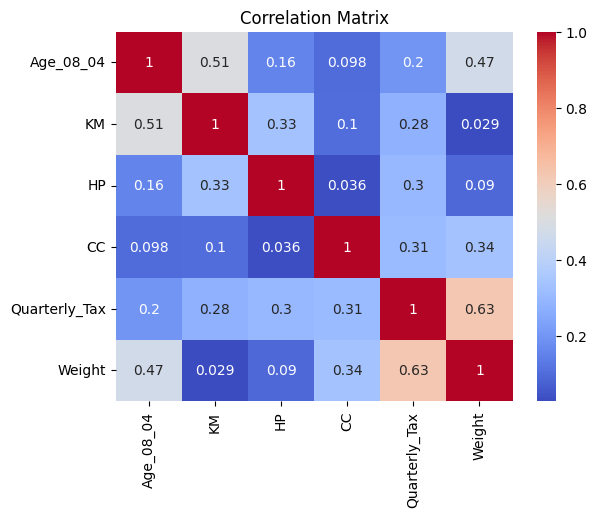

In [5]:
sns.heatmap(correlation_matrix.abs(), cmap = 'coolwarm', annot = True)
plt.title("Correlation Matrix")

Se puede apreciar que las variables `Quarterly_Tax` y `Weight` tienen una correlación de 0.63, lo cual es mayor al umbral de 0.60. Por lo tanto, estas dos variables están altamente correlacionadas y podrían ser consideradas para eliminación debido a la multicolinealidad. Asimismo, para decidí quitar la variable `Quarterly_Tax`, ya que `Weight` es una variable más fundamental que puede influir en el precio de un automóvil.

### 3.B If there are predictors that have a high absolute correlation, remove them so that the remaining predictors have a low absolute correlation between them. Otherwise, proceed to Part 4.

In [6]:
toyota_X = toyota_X.drop(columns=["Quarterly_Tax"])
print("Variables restantes:", list(toyota_X.columns))

Variables restantes: ['Age_08_04', 'KM', 'HP', 'CC', 'Weight']


## 4. Model training and interpretation

### 4.A Fit a multiple linear regression model.

The model predicts the Price in Euros of a Toyota car based on the predictors identified in Part 3. That is, the predictors that are not highly correlated.

In [7]:
X_train, X_valid, Y_train, Y_valid = train_test_split(toyota_X, toyota_Y, 
                                                      test_size = 0.25,
                                                      random_state = 301655)

In [8]:
LRmodel = LinearRegression()
LRmodel.fit(X_train, Y_train)

LinearRegression()

### 4.B Calculate and show the estimates of the coefficients ($\beta_j$'s) of the model.

In [9]:
print("Coefficients:", LRmodel.coef_)
print("Intercept:", LRmodel.intercept_)

Coefficients: [[-1.22163137e+02 -2.04137440e-02  2.90828595e+01 -1.82298069e-02
   1.75904785e+01]]
Intercept: [-2842.23620063]


### 4.D Conduct t-tests to test $H_0:\beta_j = 0$ versus $H_1:\beta_j \neq 0$ for all predictors. Identify the significant coefficients in the model. That is, the ones for which you reject $H_0$. Use an $\alpha = 0.05$. *Hint*: For this problem, you may need to fit the model in 4.A again using functions from the **statsmodels** package.

In [10]:
# Ajustar el modelo con statsmodels para obtener los p-values
X_train_sm = sm.add_constant(X_train)  # Añadir intercepto
model_sm = sm.OLS(Y_train, X_train_sm)
results_sm = model_sm.fit()

print(results_sm.summary())
print("\n" + "="*80)
print("COEFICIENTES SIGNIFICATIVOS (p-value < 0.05):")
print("="*80)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.858
Method:                 Least Squares   F-statistic:                     1301.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:07:58   Log-Likelihood:                -9301.8
No. Observations:                1077   AIC:                         1.862e+04
Df Residuals:                    1071   BIC:                         1.865e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2842.2362   1092.450     -2.602      0.0

### 4.E Based on Question 4.D, interpret the coefficients of the predictors that are significant. That is, predictors for which you rejected the $H_0: \beta_j = 0$.



Despues de analizar los resultados de los t-tests, se identificaron los siguientes coeficientes como significativos (p-value < 0.05):
- Age_08_04
- KM
- HP
- Weight

Y el unico coeficiente no significativo fue el de CC, lo cual sugiere que esta variable no tiene un impacto estadísticamente significativo en el precio de los automóviles con un un p-value de 0.843.

### Visualización de predicciones

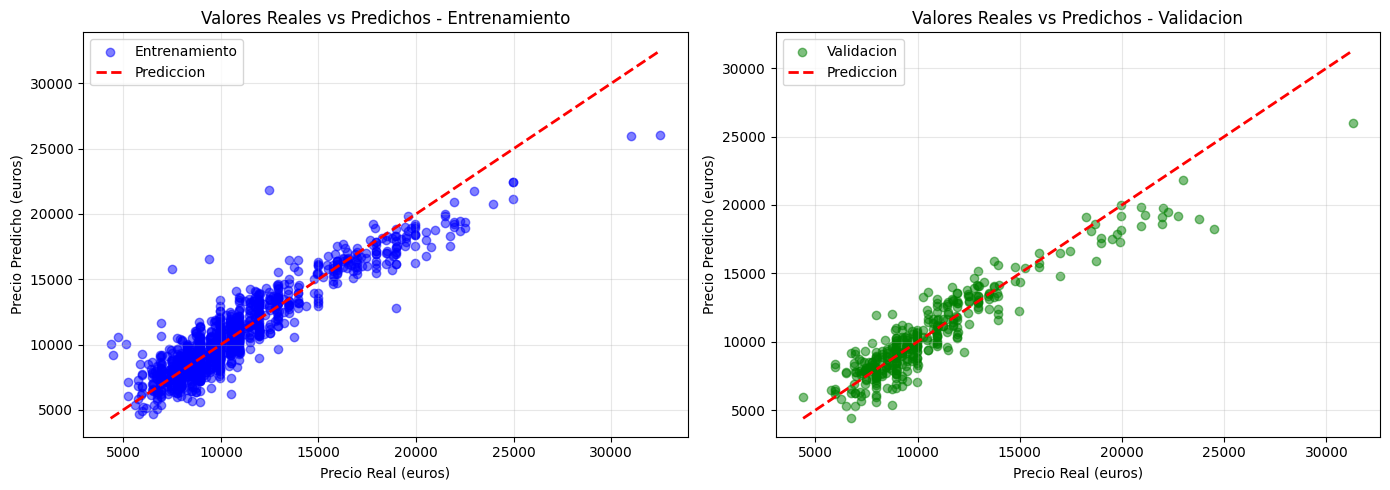

In [14]:
# Calcular predicciones
y_train_flat = Y_train.values.flatten()
y_valid_flat = Y_valid.values.flatten()
y_train_pred_flat = LRmodel.predict(X_train).flatten()
y_valid_pred_flat = LRmodel.predict(X_valid).flatten()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Valores Reales vs Predichos (Entrenamiento)
axes[0].scatter(y_train_flat, y_train_pred_flat, alpha=0.5, color='blue', label='Entrenamiento')
axes[0].plot([y_train_flat.min(), y_train_flat.max()], [y_train_flat.min(), y_train_flat.max()], 
             'r--', lw=2, label='Prediccion')
axes[0].set_xlabel('Precio Real (euros)')
axes[0].set_ylabel('Precio Predicho (euros)')
axes[0].set_title('Valores Reales vs Predichos - Entrenamiento')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Valores Reales vs Predichos (Validación)
axes[1].scatter(y_valid_flat, y_valid_pred_flat, alpha=0.5, color='green', label='Validacion')
axes[1].plot([y_valid_flat.min(), y_valid_flat.max()], [y_valid_flat.min(), y_valid_flat.max()], 
             'r--', lw=2, label='Prediccion')
axes[1].set_xlabel('Precio Real (euros)')
axes[1].set_ylabel('Precio Predicho (euros)')
axes[1].set_title('Valores Reales vs Predichos - Validacion')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Model evaluation.

### 5.A Compute a K-fold cross validation estimate of the root mean squared error. Interpret the estimate.

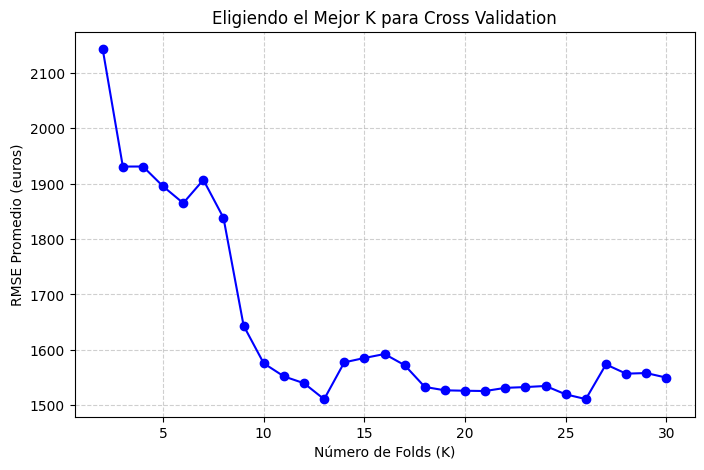


Mejor valor de K: 13
RMSE mínimo: 1510.94 euros


In [12]:
# Encontremos el mejor valor de K para Cross Validation
# Definir el rango de valores de K a probar
k_values = range(2, 31)

# Lista para almacenar los RMSE promedios
validation_rmse_values = []

for k in k_values:
    # Realizar cross validation con k folds
    cv_scores = cross_val_score(LRmodel, toyota_X, toyota_Y, 
                                cv=k, 
                                scoring='neg_mean_squared_error')
    # Convertir a RMSE promedio
    rmse_mean = np.sqrt(-cv_scores.mean())
    validation_rmse_values.append(rmse_mean)

# Visualizar los resultados
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), validation_rmse_values, marker="o", linestyle="-", color='b')
plt.xlabel("Número de Folds (K)")
plt.ylabel("RMSE Promedio (euros)")
plt.title("Eligiendo el Mejor K para Cross Validation")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Encontrar el mejor valor de K (el que minimiza RMSE)
best_k_idx = np.argmin(validation_rmse_values)
best_k = list(k_values)[best_k_idx]

print(f"\nMejor valor de K: {best_k}")
print(f"RMSE mínimo: {validation_rmse_values[best_k_idx]:.2f} euros")

In [13]:
# K-fold Cross Validation con el mejor valor de K encontrado
k_folds = best_k

# Realizamos cross validation con scoring negativo MSE
cv_scores = cross_val_score(LRmodel, toyota_X, toyota_Y, 
                            cv=k_folds, 
                            scoring='neg_mean_squared_error')

# Convertir a RMSE positivo
cv_rmse = np.sqrt(-cv_scores)

print("="*80)
print(f"K-FOLD CROSS VALIDATION (K={k_folds})")
print("="*80)
print(f"\nRMSE por cada fold:")
for i, rmse in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: {rmse:.2f} euros")

print(f"\n{'='*80}")
print(f"RMSE Promedio: {cv_rmse.mean():.2f} euros")
print(f"Desviación Estándar: {cv_rmse.std():.2f} euros")
print(f"IC 95%: [{cv_rmse.mean() - 1.96*cv_rmse.std():.2f}, {cv_rmse.mean() + 1.96*cv_rmse.std():.2f}]")
print("="*80)

K-FOLD CROSS VALIDATION (K=13)

RMSE por cada fold:
  Fold 1: 2615.53 euros
  Fold 2: 2359.22 euros
  Fold 3: 1387.13 euros
  Fold 4: 1475.31 euros
  Fold 5: 1230.08 euros
  Fold 6: 1488.95 euros
  Fold 7: 967.99 euros
  Fold 8: 1008.41 euros
  Fold 9: 1358.12 euros
  Fold 10: 1321.11 euros
  Fold 11: 1141.83 euros
  Fold 12: 976.32 euros
  Fold 13: 1280.56 euros

RMSE Promedio: 1431.58 euros
Desviación Estándar: 483.23 euros
IC 95%: [484.45, 2378.71]


**Interpretación:**

El RMSE promedio es de 1,432 euros usando K=13 folds (valor óptimo encontrado). Esto significa que cuando el modelo predice el precio de un auto, se equivoca en promedio por 1,432 euros.

Hay una variación importante entre los diferentes grupos de datos (folds). El Fold 1 tiene un error mucho mayor (2,616 euros) comparado con los mejores folds como el Fold 7 y Fold 12 (alrededor de 970 euros). Esta variación sugiere que algunos subconjuntos de datos contienen casos más difíciles de predecir o datos atípicos.

En general, el modelo funciona de manera aceptable pero no perfecta. Podría mejorarse identificando y removiendo los datos atípicos, o usando modelos más complejos.